In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Social_Network_Ads.csv')
df = df.iloc[ : ,2:]
print(df.head())
print(df.sample(5))

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
     Age  EstimatedSalary  Purchased
105   21            72000          0
394   39            59000          0
216   49            65000          0
146   27            96000          1
271   59            76000          1


In [56]:
x = df.drop('Purchased' , axis = 1)
y = df['Purchased']
x_train , x_test , y_train , y_test = train_test_split(x , y)
print(x_train.shape)
print(y_train.shape)

(300, 2)
(300,)


In [57]:
model = StandardScaler()
model.fit(x_train)
x_train_scaled = model.transform(x_train)
x_test_scaled = model.transform(x_test)

# df2 = pd.DataFrame({'Actual x_train' : x_train.iloc[ : ,0].values , 'Scaled x_train' : x_train_scaled[ : ,0] ,'Actual_x_test' : x_test.iloc[ : ,0].values ,'Scaled_x_test' : x_test_scaled[ : ,0]})
# print(df2)

df_train = pd.DataFrame({
    'Actual x_train': x_train.iloc[:, 0].values,
    'Scaled x_train': x_train_scaled[:, 0]
})

print(df_train)

df_test = pd.DataFrame({
    'Actual x_test': x_test.iloc[:, 0].values,
    'Scaled x_test': x_test_scaled[:, 0]
})

print(df_test)

     Actual x_train  Scaled x_train
0                31       -0.650854
1                35       -0.262284
2                57        1.874847
3                42        0.417712
4                31       -0.650854
..              ...             ...
295              47        0.903424
296              27       -1.039423
297              51        1.291993
298              32       -0.553711
299              37       -0.068000

[300 rows x 2 columns]
    Actual x_test  Scaled x_test
0              35      -0.262284
1              21      -1.622277
2              22      -1.525135
3              36      -0.165142
4              38       0.029143
..            ...            ...
95             35      -0.262284
96             24      -1.330850
97             55       1.680562
98             27      -1.039423
99             21      -1.622277

[100 rows x 2 columns]


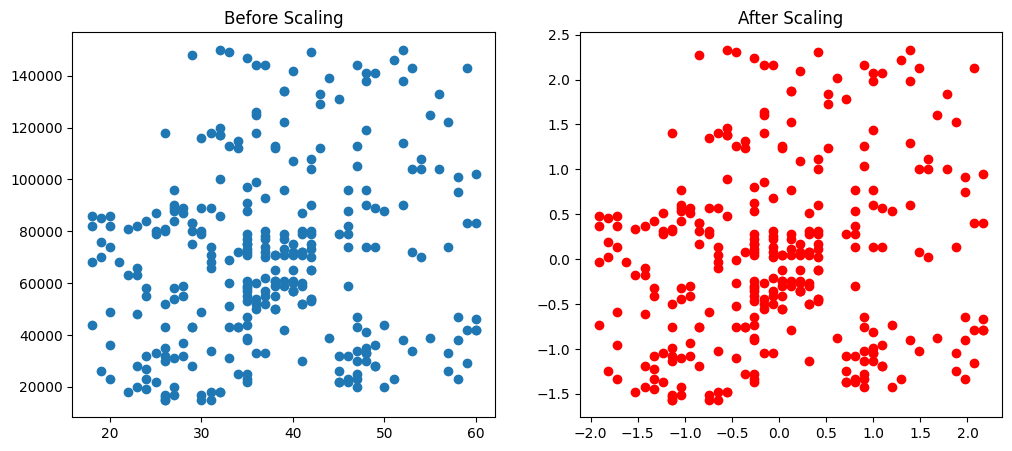

In [58]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled[: , 0], x_train_scaled[: ,1],color='red')
ax2.set_title("After Scaling")
plt.show()

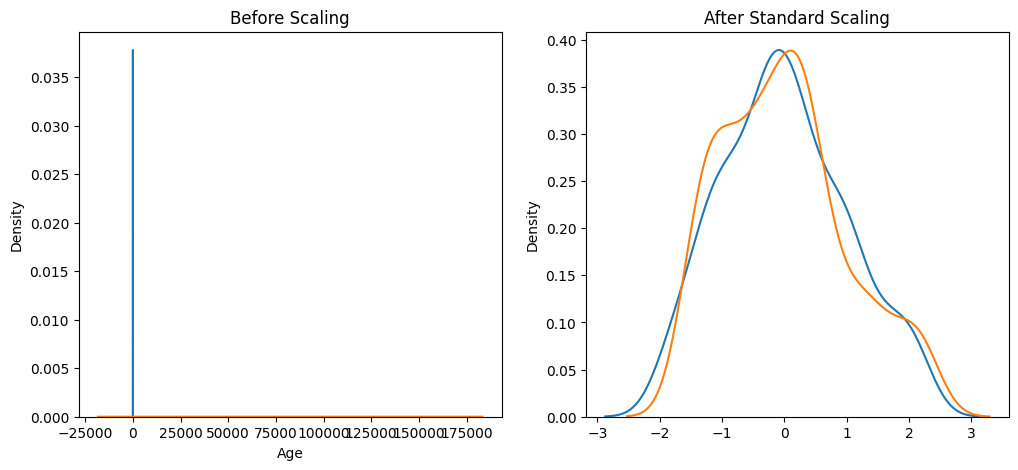

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled[ : ,0], ax=ax2)
sns.kdeplot(x_train_scaled[ : ,1], ax=ax2)
plt.show()

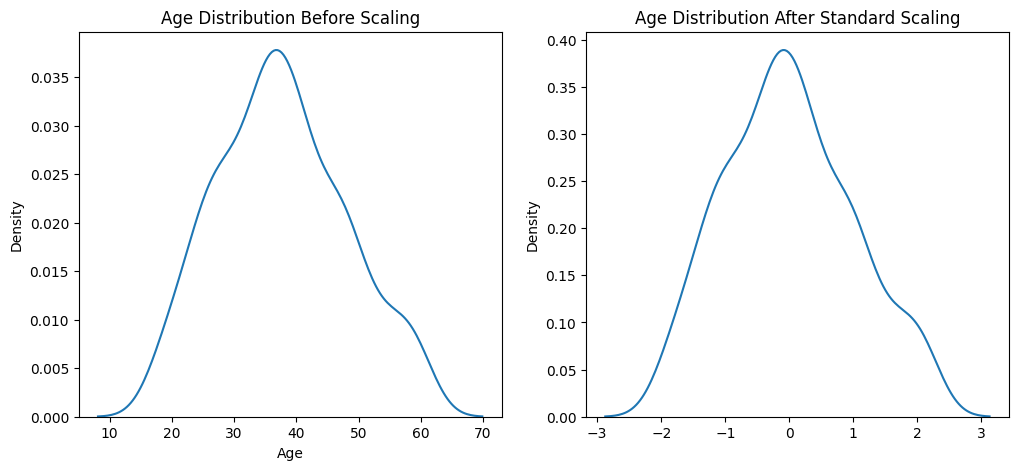

In [60]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled[ : ,0], ax=ax2)
plt.show()

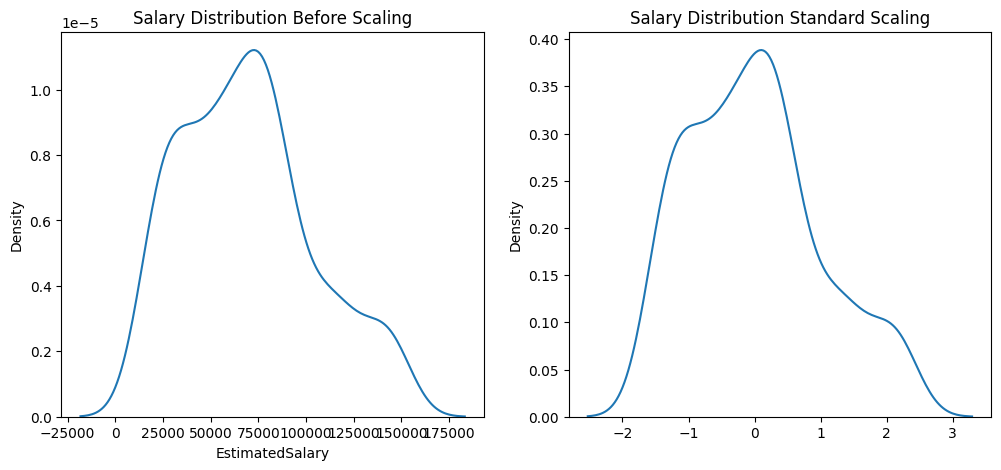

In [61]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(x_train_scaled[ : ,1], ax=ax2)
plt.show()

WHY FEATURE SCALLING IS IMPORTANT

In [62]:
model1 = LogisticRegression()
model1.fit(x_train , y_train)
y_pred1 = model1.predict(x_test)

In [63]:
model2 = LogisticRegression()
model2.fit(x_train_scaled , y_train)
y_pred2 = model2.predict(x_test_scaled)

In [64]:
df3 = pd.DataFrame({ 'Actual y_test ': y_test.values ,
                    'Predicted y_pred1' : y_pred1})
print(df3.sample(20))
print("Classification Report :- \n" ,classification_report(y_test ,y_pred1))
print("Accuracy Score :- \n" , accuracy_score(y_test ,y_pred1))
print("Confucsion Matrix :- \n" , confusion_matrix(y_test , y_pred1))

    Actual y_test   Predicted y_pred1
86               0                  0
7                1                  1
13               0                  0
78               0                  0
77               1                  1
43               1                  0
48               0                  0
37               0                  0
51               0                  0
68               1                  1
53               0                  0
49               0                  0
62               0                  0
67               0                  0
42               1                  0
16               0                  0
10               0                  0
20               1                  1
1                0                  0
6                0                  0
Classification Report :- 
               precision    recall  f1-score   support

           0       0.85      0.97      0.90        62
           1       0.93      0.71      0.81        38

    accurac

In [72]:
df4 = pd.DataFrame({ 'Actual y_test ': y_test.values ,
                    'Predicted y_pred1' : y_pred2})
print(df4.sample(20))
print("Classification Report :- \n" ,classification_report(y_test ,y_pred2))
print("Accuracy Score :- \n" , accuracy_score(y_test ,y_pred2))
print("Confucsion Matrix :- \n" , confusion_matrix(y_test , y_pred2))

    Actual y_test   Predicted y_pred1
49               0                  0
27               1                  1
41               1                  1
79               0                  0
71               1                  0
37               0                  0
29               0                  0
98               1                  0
11               1                  0
59               0                  0
34               1                  1
87               1                  0
54               0                  0
89               1                  1
18               0                  0
57               0                  0
40               0                  0
17               1                  1
39               0                  0
61               0                  0
Classification Report :- 
               precision    recall  f1-score   support

           0       0.85      0.97      0.90        62
           1       0.93      0.71      0.81        38

    accurac

In [70]:
model3 = DecisionTreeClassifier()
model3.fit(x_train , y_train)
y_pred3 = model3.predict(x_test)

In [71]:
model4 = DecisionTreeClassifier()
model4.fit(x_train_scaled , y_train)
y_pred4 = model4.predict(x_test_scaled)

In [73]:
df5 = pd.DataFrame({ 'Actual y_test ': y_test.values ,
                    'Predicted y_pred1' : y_pred3})
print(df5.sample(20))
print("Classification Report :- \n" ,classification_report(y_test ,y_pred3))
print("Accuracy Score :- \n" , accuracy_score(y_test ,y_pred3))
print("Confucsion Matrix :- \n" , confusion_matrix(y_test , y_pred3))

    Actual y_test   Predicted y_pred1
63               1                  1
72               0                  0
4                0                  0
79               0                  0
8                0                  0
93               1                  0
5                0                  0
97               1                  1
90               0                  0
27               1                  1
87               1                  0
47               1                  1
20               1                  1
31               0                  0
38               1                  1
48               0                  0
98               1                  1
84               0                  0
70               0                  0
28               1                  0
Classification Report :- 
               precision    recall  f1-score   support

           0       0.86      0.95      0.90        62
           1       0.90      0.74      0.81        38

    accurac

In [75]:
df5 = pd.DataFrame({ 'Actual y_test ': y_test.values ,
                    'Predicted y_pred1' : y_pred4})
print(df5.sample(20))
print("Classification Report :- \n" ,classification_report(y_test ,y_pred4))
print("Accuracy Score :- \n" , accuracy_score(y_test ,y_pred4))
print("Confucsion Matrix :- \n" , confusion_matrix(y_test , y_pred4))

    Actual y_test   Predicted y_pred1
53               0                  0
77               1                  0
52               0                  0
46               0                  0
20               1                  1
45               1                  1
50               1                  1
21               0                  0
69               1                  0
64               1                  1
25               0                  0
31               0                  0
73               0                  0
23               0                  0
65               0                  0
9                1                  1
80               1                  0
78               0                  0
54               0                  0
38               1                  1
Classification Report :- 
               precision    recall  f1-score   support

           0       0.87      0.95      0.91        62
           1       0.91      0.76      0.83        38

    accurac

Effects of Oulier

In [78]:
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

df = pd.concat([df, new_data], ignore_index=True)

print(df.tail())

     Age  EstimatedSalary  Purchased
398   36            33000          0
399   49            36000          1
400    5             1000          0
401   90           250000          1
402   95           350000          1


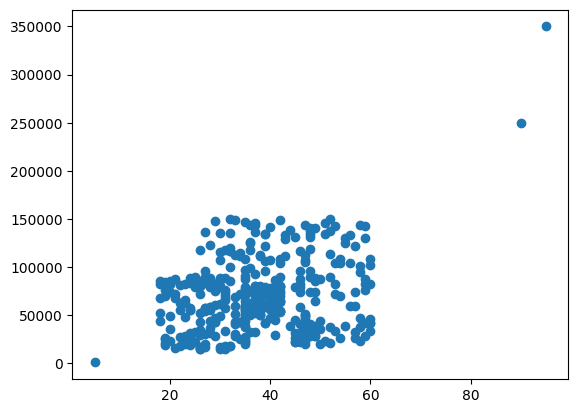

In [79]:
plt.scatter(df['Age'], df['EstimatedSalary'])